In [ ]:
#load dataset
import os
if not os.path.exists('COVID_19_dataset'):
  !unzip /content/COVID_19_dataset.zip

Archive:  /content/COVID_19_dataset.zip
   creating: COVID_19_dataset/
  inflating: COVID_19_dataset/.DS_Store  
   creating: COVID_19_dataset/test/
  inflating: COVID_19_dataset/test/.DS_Store  
   creating: COVID_19_dataset/test/COVID/
  inflating: COVID_19_dataset/test/COVID/COVID-1010.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1015.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1040.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1054.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1074.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1098.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1112.png  
  inflating: COVID_19_dataset/test/COVID/COVID-114.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1146.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1206.png  
  inflating: COVID_19_dataset/test/COVID/COVID-122.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1258.png  
  inflating: COVID_19_dataset/test/COVID/COVID-1284.png  
  inflatin

In [ ]:
!pip install timm torch torchvision scikit-learn seaborn matplotlib

In [ ]:
#install lib
import os
import torch
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [ ]:
dataset_path = "/content/COVID_19_dataset"

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

image transformation(Augmentation)


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

print(train_dataset.classes)

['COVID', 'Normal', 'Viral Pneumonia']


DataLoader

In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

Loading Pretrained VIT

In [ ]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True
)

num_features = model.head.in_features

model.head = nn.Linear(
    num_features,
    3
)

model = model.to(device)

print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

setting hyperparameters

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

training function

In [ ]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

validation func

In [ ]:
def validate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = running_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

training loop

In [ ]:
epochs = 10

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_vit.pth"
        )

Epoch [1/10] Train Loss: 0.8025 Val Loss: 0.3474 Train Acc: 0.6390 Val Acc: 0.8517
Epoch [2/10] Train Loss: 0.3215 Val Loss: 0.2328 Train Acc: 0.8660 Val Acc: 0.9050
Epoch [3/10] Train Loss: 0.2132 Val Loss: 0.2686 Train Acc: 0.9167 Val Acc: 0.9017
Epoch [4/10] Train Loss: 0.1838 Val Loss: 0.1734 Train Acc: 0.9303 Val Acc: 0.9283
Epoch [5/10] Train Loss: 0.1577 Val Loss: 0.0855 Train Acc: 0.9383 Val Acc: 0.9567
Epoch [6/10] Train Loss: 0.1282 Val Loss: 0.1329 Train Acc: 0.9533 Val Acc: 0.9383
Epoch [7/10] Train Loss: 0.1212 Val Loss: 0.1897 Train Acc: 0.9517 Val Acc: 0.9317
Epoch [8/10] Train Loss: 0.1116 Val Loss: 0.1519 Train Acc: 0.9577 Val Acc: 0.9433
Epoch [9/10] Train Loss: 0.1115 Val Loss: 0.1046 Train Acc: 0.9580 Val Acc: 0.9583
Epoch [10/10] Train Loss: 0.0730 Val Loss: 0.1475 Train Acc: 0.9727 Val Acc: 0.9483


save the model

In [ ]:
model.load_state_dict(
    torch.load("best_vit.pth")
)

model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

Evaluate on Test Data

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        total += labels.size(0)

        correct += (preds == labels).sum().item()

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 97.01%


Plot Loss curve

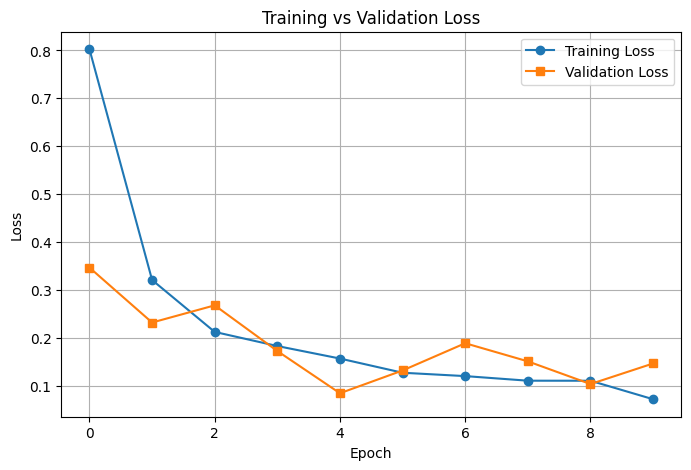

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label='Training Loss',
    marker='o'
)

plt.plot(
    val_losses,
    label='Validation Loss',
    marker='s'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

Plot Accuracy curve

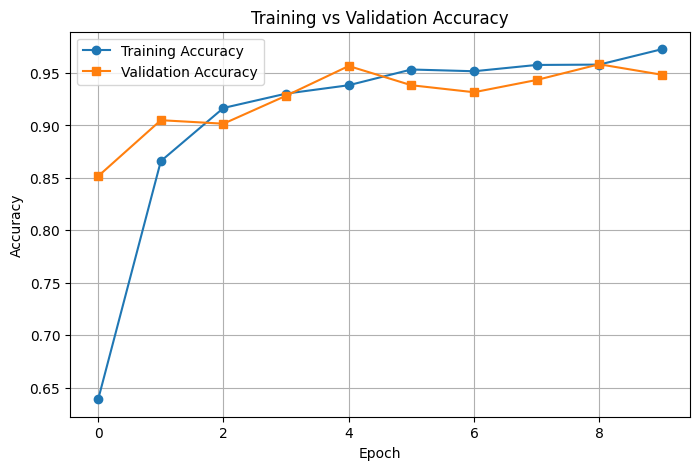

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label='Training Accuracy',
    marker='o'
)

plt.plot(
    val_accs,
    label='Validation Accuracy',
    marker='s'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()

Performance Metrics

In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9701149425287356
Precision: 0.9710632157440668
Recall   : 0.9701149425287356
F1 Score : 0.9701325879815582


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.classes
    )
)

                 precision    recall  f1-score   support

          COVID       0.94      1.00      0.97       145
         Normal       0.97      0.94      0.96       145
Viral Pneumonia       1.00      0.97      0.98       145

       accuracy                           0.97       435
      macro avg       0.97      0.97      0.97       435
   weighted avg       0.97      0.97      0.97       435



Confusion Matrix

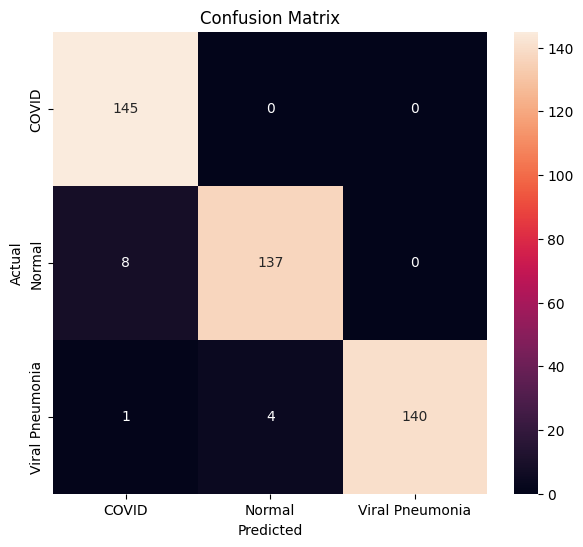

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install lime shap opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=80aa7f0db8bb62e9c14bd19930df91a248406b91af20f860ddc2a3729ecdaa46
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Prediction Observation

In [ ]:
import cv2
import timm
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

import shap
from lime import lime_image

from skimage.segmentation import mark_boundaries

In [ ]:
classes = [
    "COVID",
    "Normal",
    "Viral Pneumonia"
]

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

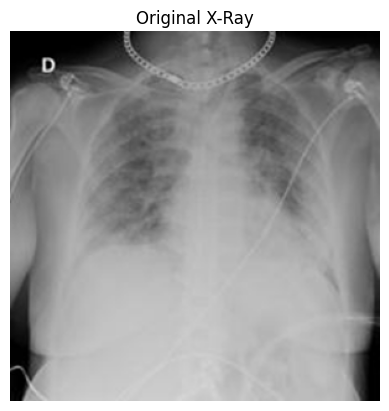

In [ ]:
img_path = "/content/COVID_19_dataset/test/COVID/COVID-1010.png"

image = Image.open(img_path).convert("RGB")

plt.imshow(image)
plt.title("Original X-Ray")
plt.axis("off")
plt.show()

In [ ]:
def predict_image(img):

    x = transform(img)

    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        out = model(x)

        probs = torch.softmax(
            out,
            dim=1
        )

    pred = torch.argmax(
        probs,
        dim=1
    ).item()

    confidence = probs[0][pred].item()

    return pred, confidence

In [ ]:
pred_class, confidence = predict_image(image)

print("Prediction :", classes[pred_class])
print("Confidence :", confidence)

Prediction : COVID
Confidence : 0.941868007183075


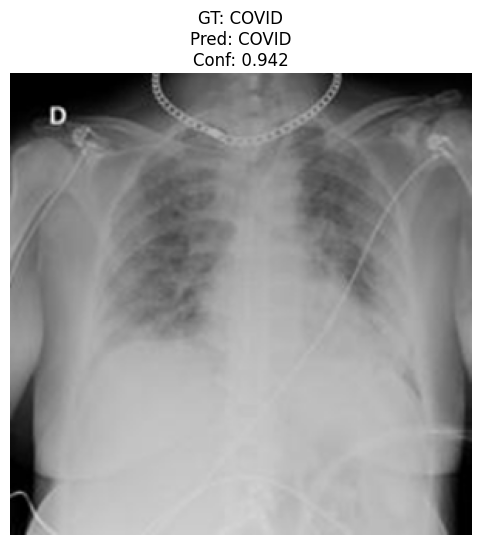

In [ ]:
ground_truth = "COVID"

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(
    f"GT: {ground_truth}\n"
    f"Pred: {classes[pred_class]}\n"
    f"Conf: {confidence:.3f}"
)

plt.axis("off")
plt.show()